## Exploratory Data Analysis for the Titanic dataset.
first understand the data before touching any modeling code.

In [45]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\2573213744.py:6: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed in 3.10.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("Agg")


In [58]:
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

sys.path.insert(0, BASE_DIR)

TRAIN_PATH = "./dataset/train.csv"
TEST_PATH = "./dataset/test.csv"

OUTPUT_PATH = "./eda_output"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load Dataset

In [57]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

def describe_dataset(df, name="dataset", target="Survived"):
    bar = "=" * 60
    print(f"\n{bar}\n{name.upper()}\n{bar}")

    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print("\n--- Columns & dtypes ---")
    print(df.dtypes.to_string())

    num_df = df.select_dtypes(include="number")
    if not num_df.empty:
        print("\n--- Numeric summary ---")
        print(num_df.describe().T.round(3).to_string())

    cat_df = df.select_dtypes(include=["object", "category", "str"])
    if not cat_df.empty:
        print("\n--- Categorical summary (top 5 per column) ---")
        for col in cat_df.columns:
            vc = df[col].value_counts(dropna=False).head(5)
            n_unique = df[col].nunique(dropna=True)
            print(f"\n[{col}]  (unique: {n_unique})")
            for val, cnt in vc.items():
                pct = 100 * cnt / len(df)
                print(f"   {str(val)[:40]:<42} {cnt:>5}  ({pct:5.1f}%)")

    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print("\n--- Missing values ---")
    if miss.empty:
        print("   (none)")
    else:
        for col, cnt in miss.items():
            print(f"   {col:<15} {cnt:>5}  ({100*cnt/len(df):5.1f}%)")

    if target in df.columns:
        print(f"\n--- Target distribution: {target} ---")
        vc = df[target].value_counts().sort_index()
        vc_pct = df[target].value_counts(normalize=True).sort_index()
        for k in vc.index:
            print(f"   {k}: {vc[k]:>5}  ({vc_pct[k]*100:5.1f}%)")

describe_dataset(train, "Train", target="Survived")
describe_dataset(test,  "Test",  target="Survived")  


TRAIN
Shape: 891 rows × 12 columns

--- Columns & dtypes ---
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str

--- Numeric summary ---
             count     mean      std   min      25%      50%    75%      max
PassengerId  891.0  446.000  257.354  1.00  223.500  446.000  668.5  891.000
Survived     891.0    0.384    0.487  0.00    0.000    0.000    1.0    1.000
Pclass       891.0    2.309    0.836  1.00    2.000    3.000    3.0    3.000
Age          714.0   29.699   14.526  0.42   20.125   28.000   38.0   80.000
SibSp        891.0    0.523    1.103  0.00    0.000    0.000    1.0    8.000
Parch        891.0    0.382    0.806  0.00    0.000    0.000    0.0    6.000
Fare         891.0   32.204   49.693  0.00    7.910   14.454   31.0  512.329

--- Categorical summ

# Basic Overview

In [18]:
print("=" * 60)
print("SHAPES")
print("=" * 60)
print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\n" + "=" * 60)
print("HEAD")
print("=" * 60)
print(train.head())

print("\n" + "=" * 60)
print("INFO")
print("=" * 60)
print(train.info())

print("\n" + "=" * 60)
print("MISSING VALUES (train)")
print("=" * 60)
print(train.isnull().sum())

print("\n" + "=" * 60)
print("MISSING VALUES (test)")
print("=" * 60)
print(test.isnull().sum())

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(train["Survived"].value_counts())
print(train["Survived"].value_counts(normalize=True))

print("\n" + "=" * 60)
print("DESCRIBE (numeric)")
print("=" * 60)
print(train.describe())

SHAPES
Train shape: (891, 12)
Test shape : (418, 11)

HEAD
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        

In [19]:
def survival_by_group(train, col):
    rate = train.groupby(col)["Survived"].mean().sort_values(ascending=False)
    print(f"\nSurvival rate by {col}:\n{rate}")
    return rate

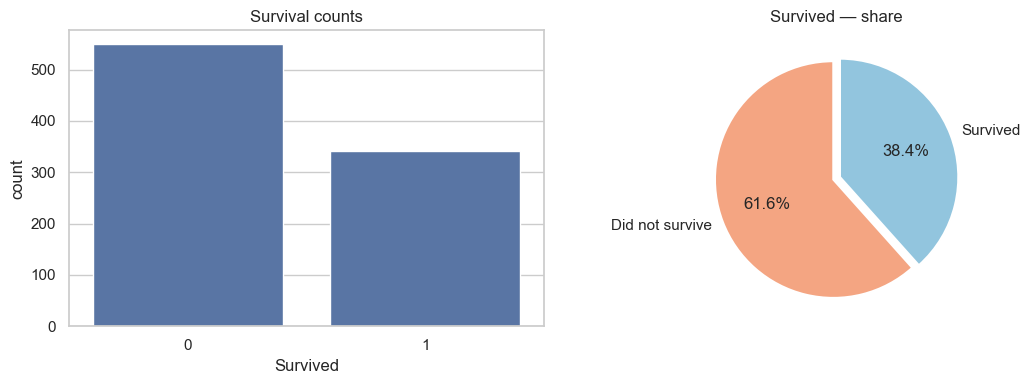

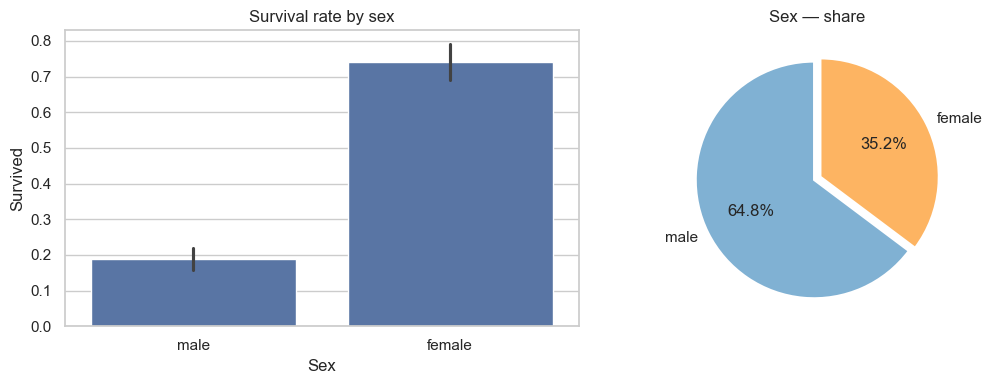

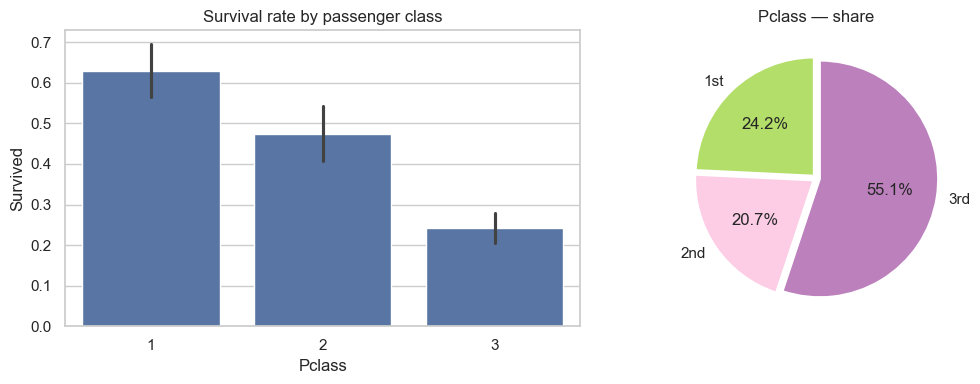

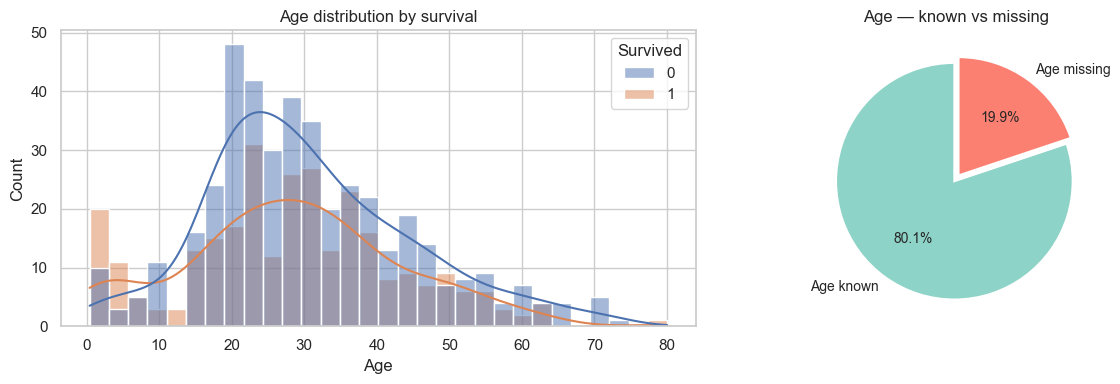

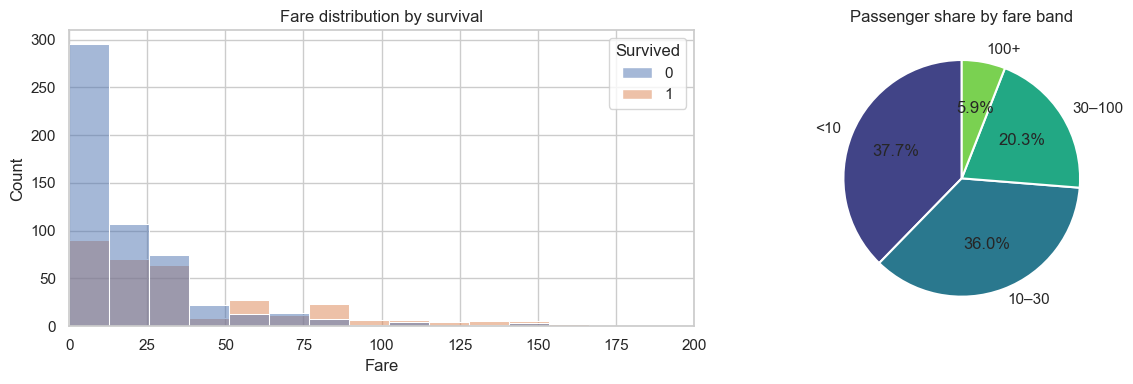

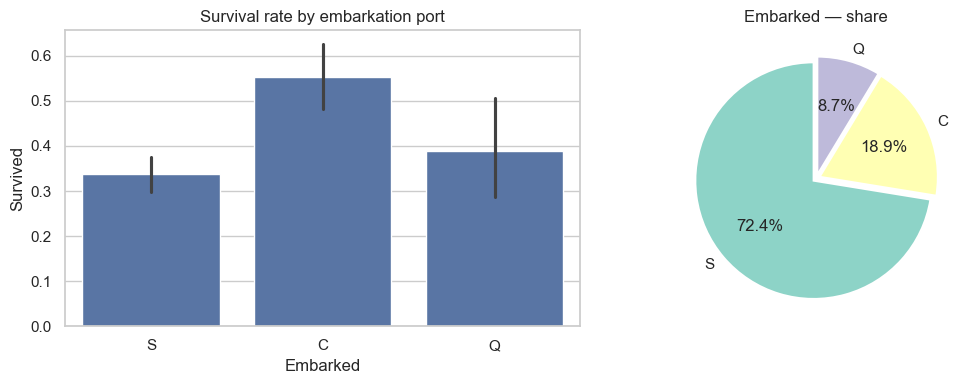


Plots saved to: ./eda_output


In [54]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=train, x="Survived", ax=axes[0])
axes[0].set_title("Survival counts")

train["Survived"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    labels=["Did not survive", "Survived"],
    colors=["#f4a582", "#92c5de"], explode=(0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, ylabel="",
)
axes[1].set_title("Survived — share")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_counts.png", bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=train, x="Sex", y="Survived", ax=axes[0])
axes[0].set_title("Survival rate by sex")

train["Sex"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=["#80b1d3", "#fdb462"], explode=(0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, ylabel="",
)
axes[1].set_title("Sex — share")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_sex.png", bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=train, x="Pclass", y="Survived", ax=axes[0])
axes[0].set_title("Survival rate by passenger class")

train["Pclass"].value_counts().sort_index().plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    labels=["1st", "2nd", "3rd"],
    colors=["#b3de69", "#fccde5", "#bc80bd"], explode=(0.03, 0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, ylabel="",
)
axes[1].set_title("Pclass — share")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_pclass.png", bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age distribution by survival")

# Pie of Age present vs missing — relevant because Age has NaN
age_present = train["Age"].notna().value_counts().rename({True: "Age known", False: "Age missing"})
axes[1].pie(
    age_present.values, labels=age_present.index, autopct="%1.1f%%",
    startangle=90, colors=["#8dd3c7", "#fb8072"], explode=(0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 10},
)
axes[1].set_title("Age — known vs missing")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/age_by_survival.png", bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=train, x="Fare", hue="Survived", bins=40, ax=axes[0])
axes[0].set_title("Fare distribution by survival")
axes[0].set_xlim(0, 200)

fare_band = pd.cut(train["Fare"], bins=[-0.01, 10, 30, 100, 600],
                   labels=["<10", "10–30", "30–100", "100+"])
fare_band.value_counts().reindex(["<10", "10–30", "30–100", "100+"]).plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=sns.color_palette("viridis", 4),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, ylabel="",
)
axes[1].set_title("Passenger share by fare band")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/fare_by_survival.png", bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=train, x="Embarked", y="Survived", ax=axes[0])
axes[0].set_title("Survival rate by embarkation port")

train["Embarked"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=["#8dd3c7", "#ffffb3", "#bebada"], explode=(0.03, 0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, ylabel="",
)
axes[1].set_title("Embarked — share")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_embarked.png", bbox_inches="tight")
plt.show()
plt.close()


print(f"\nPlots saved to: {OUTPUT_PATH}")

In [31]:
survival_by_group(train, "Sex")
survival_by_group(train, "Pclass")
survival_by_group(train, "Embarked")


Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

# Missing values bar chart (train + test side by side)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\3786341723.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss.values, y=miss.index,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\3786341723.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss.values, y=miss.index,


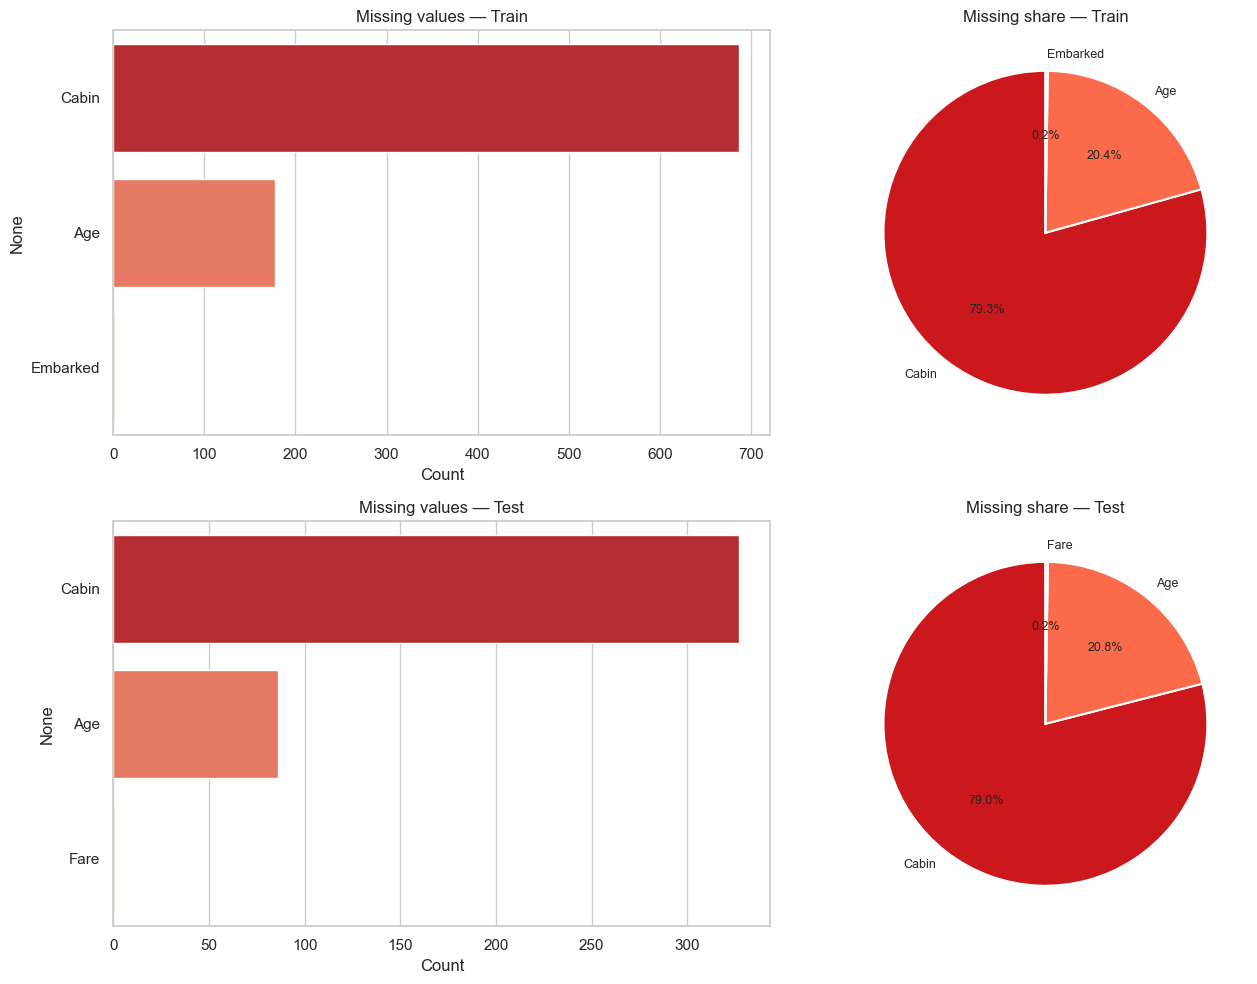

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (df, name) in enumerate(zip([train, test], ["Train", "Test"])):
    miss = df.isnull().sum().sort_values(ascending=False)
    miss = miss[miss > 0]

    sns.barplot(x=miss.values, y=miss.index,
                ax=axes[row, 0], palette="Reds_r")
    axes[row, 0].set_title(f"Missing values — {name}")
    axes[row, 0].set_xlabel("Count")

    colors = sns.color_palette("Reds_r", len(miss))
    axes[row, 1].pie(
        miss.values,
        labels=miss.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        textprops={"fontsize": 9},
    )
    axes[row, 1].set_title(f"Missing share — {name}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/missing_values.png", bbox_inches="tight")
plt.show()
plt.close()

# Numerical feature distributions (Age, Fare, SibSp, Parch)

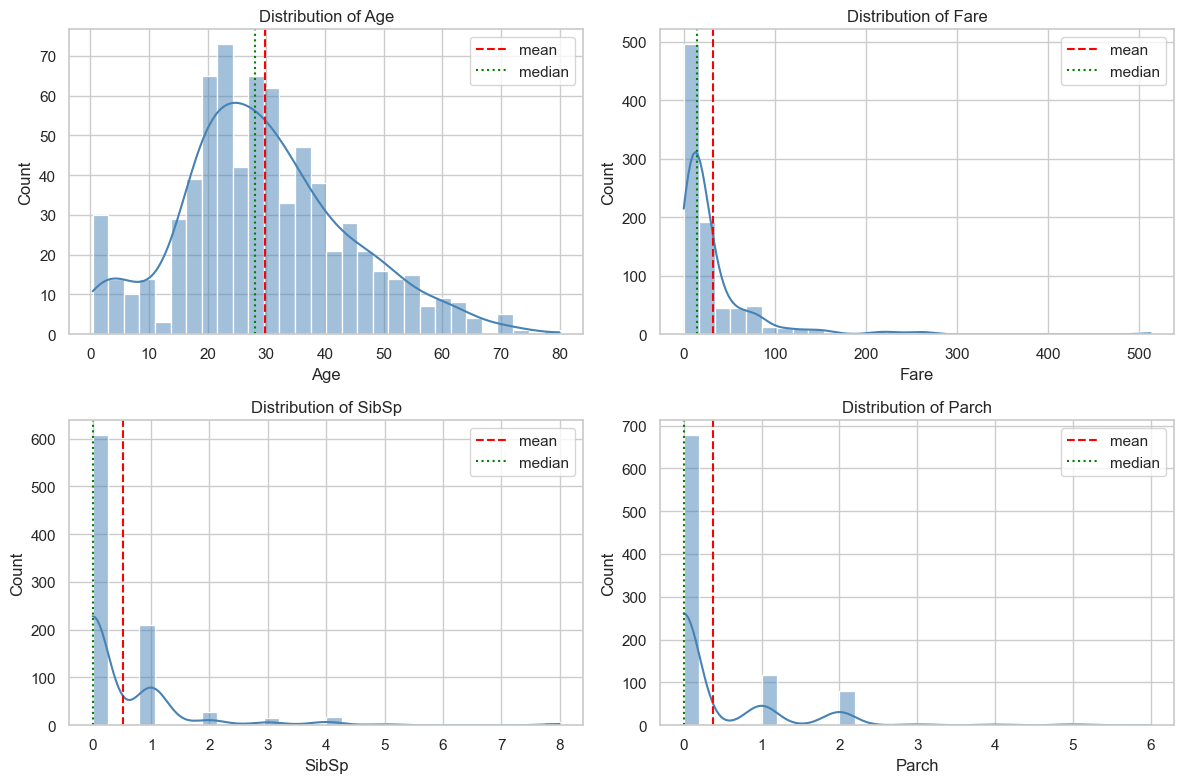

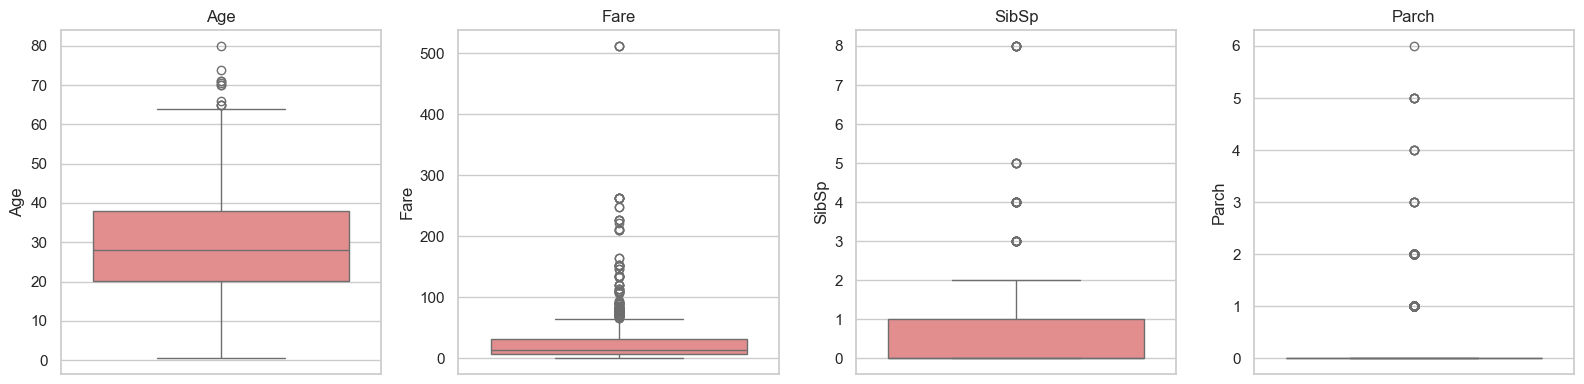

In [35]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(train[col], kde=True, ax=ax, bins=30, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.axvline(train[col].mean(),   color="red",   linestyle="--", label="mean")
    ax.axvline(train[col].median(), color="green", linestyle=":",  label="median")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/num_distributions.png", bbox_inches="tight")
plt.show()
plt.close()

# Boxplots to spot outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=train[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/num_boxplots.png", bbox_inches="tight")
plt.show()
plt.close()

# Correlation heatmap

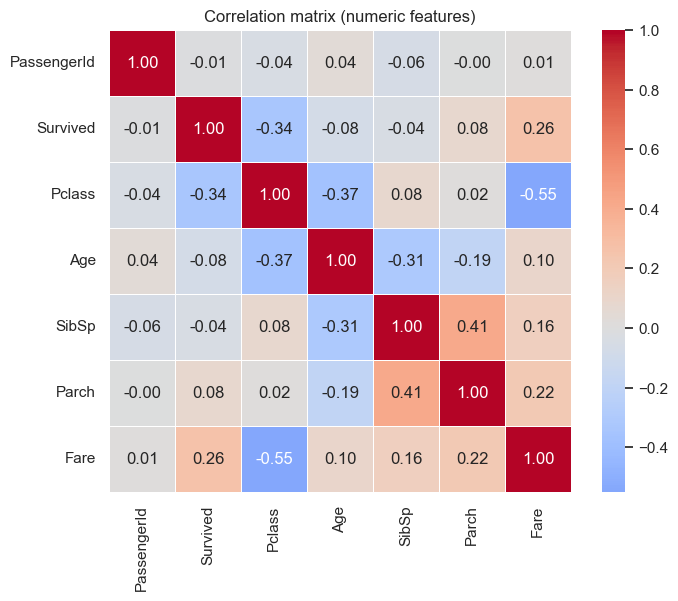

In [36]:
plt.figure(figsize=(8, 6))
corr = train.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation matrix (numeric features)")
plt.savefig(f"{OUTPUT_PATH}/correlation_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

# Survival by Sex and Pclass (interaction)

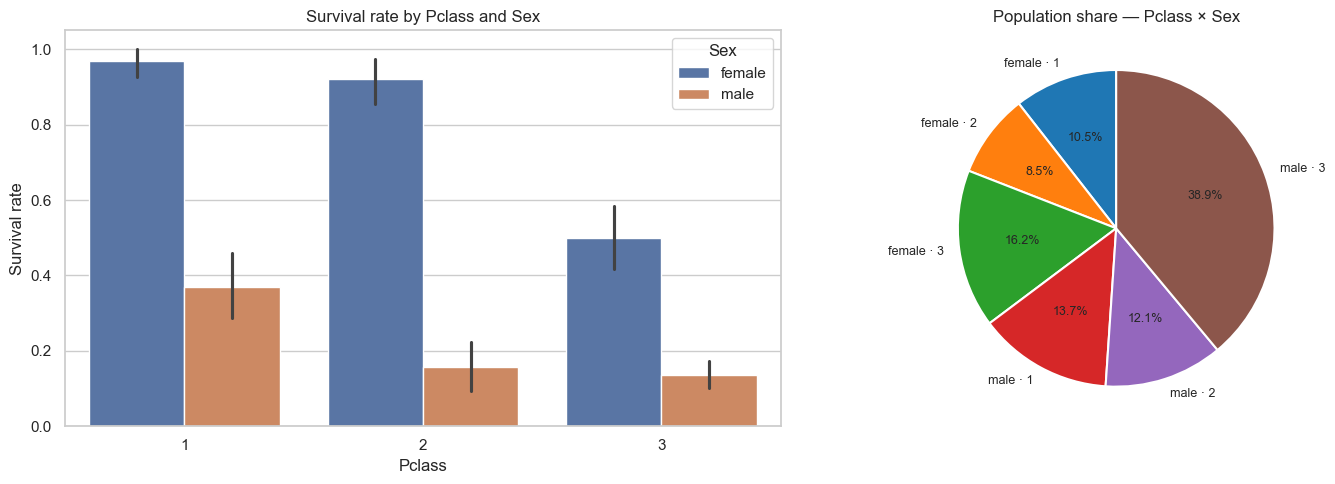

Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


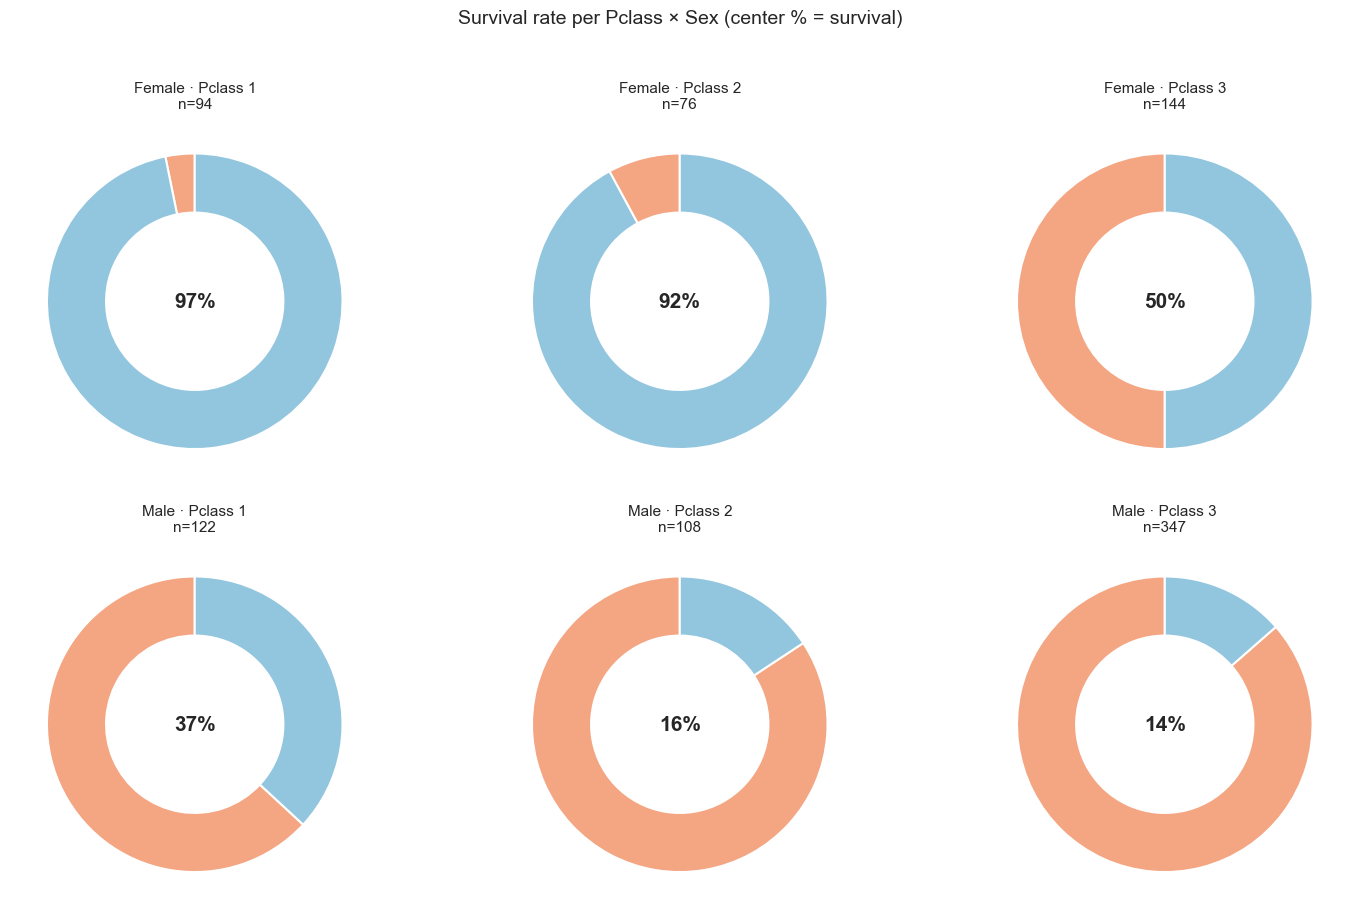

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=train, x="Pclass", y="Survived", hue="Sex", ax=axes[0])
axes[0].set_title("Survival rate by Pclass and Sex")
axes[0].set_ylabel("Survival rate")

train["SexPclass"] = train["Sex"].astype(str) + " · " + train["Pclass"].astype(str)
order_sp = ["female · 1", "female · 2", "female · 3",
            "male · 1",   "male · 2",   "male · 3"]

counts = train["SexPclass"].value_counts().reindex(order_sp)
colors = sns.color_palette("tab10", len(counts))

axes[1].pie(
    counts.values, labels=counts.index, autopct="%1.1f%%",
    startangle=90, colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
axes[1].set_title("Population share — Pclass × Sex")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_pclass_sex.png", bbox_inches="tight")
plt.show()
plt.close()

# Pivot table as numbers too
print(train.pivot_table("Survived", index="Pclass", columns="Sex", aggfunc="mean"))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, sex in enumerate(["female", "male"]):
    for col, pclass in enumerate([1, 2, 3]):
        ax = axes[row, col]
        sub = train[(train["Sex"] == sex) & (train["Pclass"] == pclass)]
        vc = sub["Survived"].value_counts().reindex([0, 1], fill_value=0)

        ax.pie(
            vc.values,
            colors=["#f4a582", "#92c5de"],
            startangle=90,
            wedgeprops={"width": 0.40, "edgecolor": "white", "linewidth": 1.5},
        )
        rate = sub["Survived"].mean()
        ax.text(0, 0, f"{rate*100:.0f}%",
                ha="center", va="center", fontsize=15, fontweight="bold")
        ax.set_title(f"{sex.capitalize()} · Pclass {pclass}\nn={len(sub)}",
                     fontsize=11)

fig.suptitle("Survival rate per Pclass × Sex (center % = survival)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_pclass_sex_donuts.png", bbox_inches="tight")
plt.show()
plt.close()

# categorical proportions

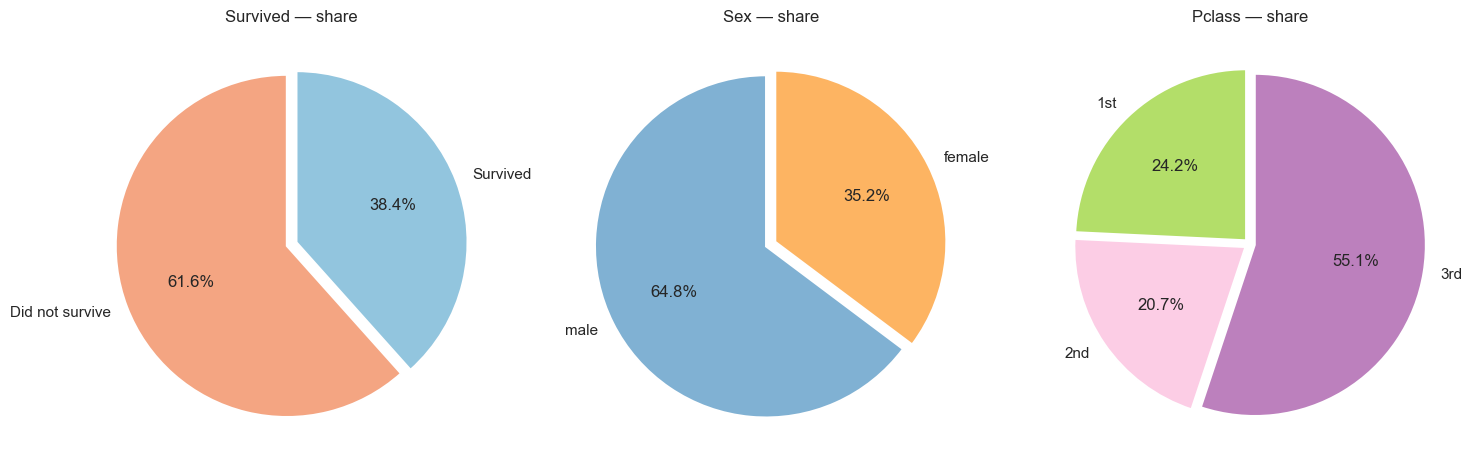

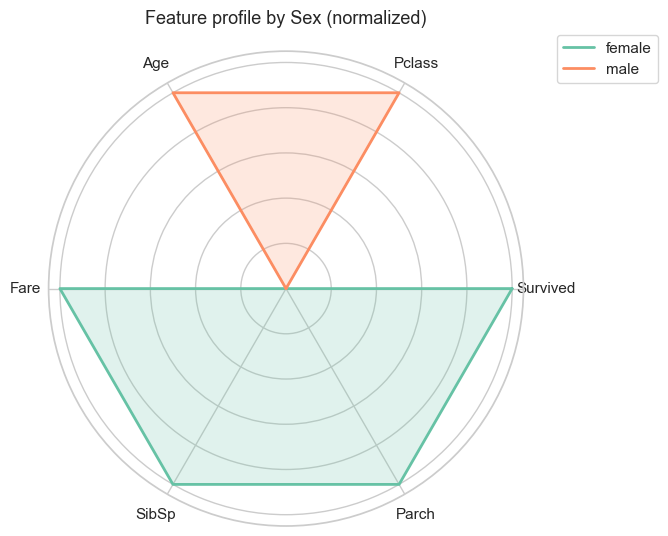

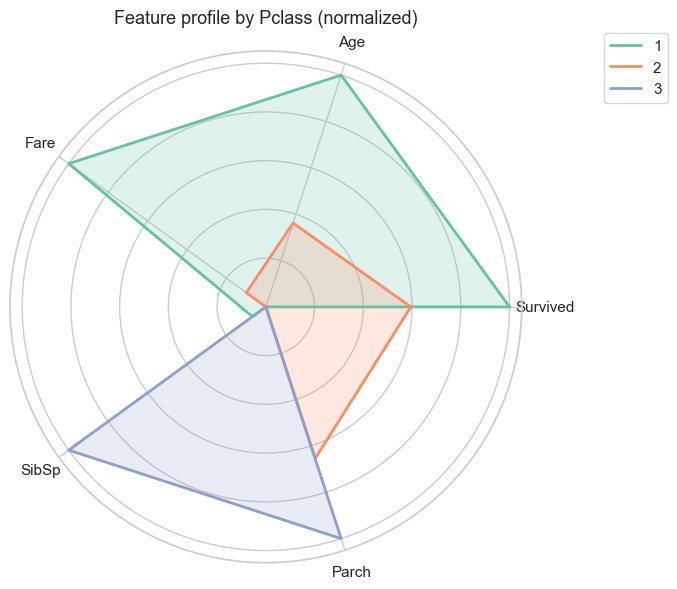

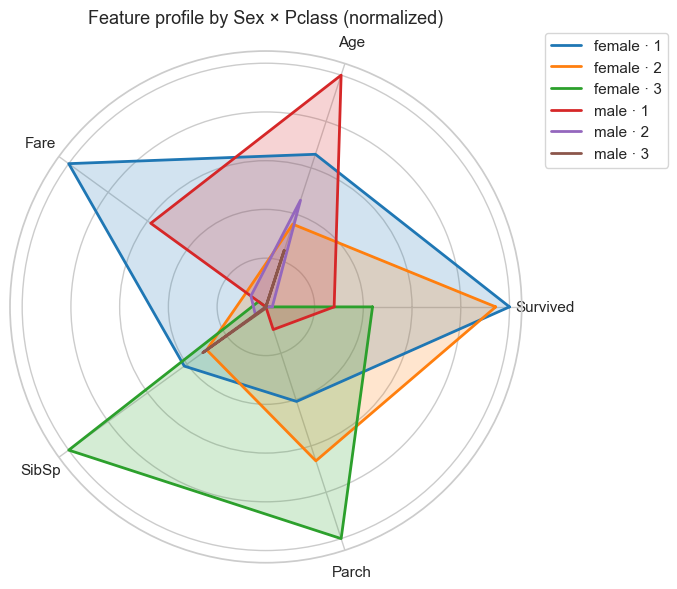

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Target
train["Survived"].value_counts().plot.pie(
    ax=axes[0], autopct="%1.1f%%", startangle=90,
    labels=["Did not survive", "Survived"],
    colors=["#f4a582", "#92c5de"], explode=(0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    ylabel=""
)
axes[0].set_title("Survived — share")

# Sex
train["Sex"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=["#80b1d3", "#fdb462"], explode=(0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    ylabel=""
)
axes[1].set_title("Sex — share")

# Pclass
train["Pclass"].value_counts().sort_index().plot.pie(
    ax=axes[2], autopct="%1.1f%%", startangle=90,
    labels=["1st", "2nd", "3rd"],
    colors=["#b3de69", "#fccde5", "#bc80bd"], explode=(0.03, 0.03, 0.03),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    ylabel=""
)
axes[2].set_title("Pclass — share")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/pies_overview.png", bbox_inches="tight")
plt.show()
plt.close()

def radar_chart(df, group_col, feature_cols, normalize=True,
                title="Radar chart", fname="radar.png",
                order=None, palette="Set2"):
    """Radar chart comparing group means across numeric features."""
    agg = df.groupby(group_col, observed=True)[feature_cols].mean()
    if order is not None:
        agg = agg.reindex(order)
    norm = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9) if normalize else agg

    N = len(feature_cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = sns.color_palette(palette, len(norm))

    for (label, row), color in zip(norm.iterrows(), colors):
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, linewidth=2, label=str(label), color=color)
        ax.fill(angles, vals, alpha=0.20, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_cols, fontsize=11)
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.05))
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/{fname}", bbox_inches="tight")
    plt.show()
    plt.close()

radar_chart(
    train, "Sex",
    feature_cols=["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"],
    title="Feature profile by Sex (normalized)",
    fname="radar_by_sex.png",
    order=["female", "male"],
    palette="Set2",
)

radar_chart(
    train, "Pclass",
    feature_cols=["Survived", "Age", "Fare", "SibSp", "Parch"],
    order=[1, 2, 3],
    title="Feature profile by Pclass (normalized)",
    fname="radar_by_pclass.png",
    palette="Set2",
)

train["SexPclass"] = train["Sex"].astype(str) + " · " + train["Pclass"].astype(str)
order_sp = ["female · 1", "female · 2", "female · 3",
            "male · 1",   "male · 2",   "male · 3"]

radar_chart(
    train, "SexPclass",
    feature_cols=["Survived", "Age", "Fare", "SibSp", "Parch"],
    order=order_sp,
    title="Feature profile by Sex × Pclass (normalized)",
    fname="radar_by_sex_pclass.png",
    palette="tab10",
)

# Family size feature

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\682107021.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="FamilySize", y="Survived",


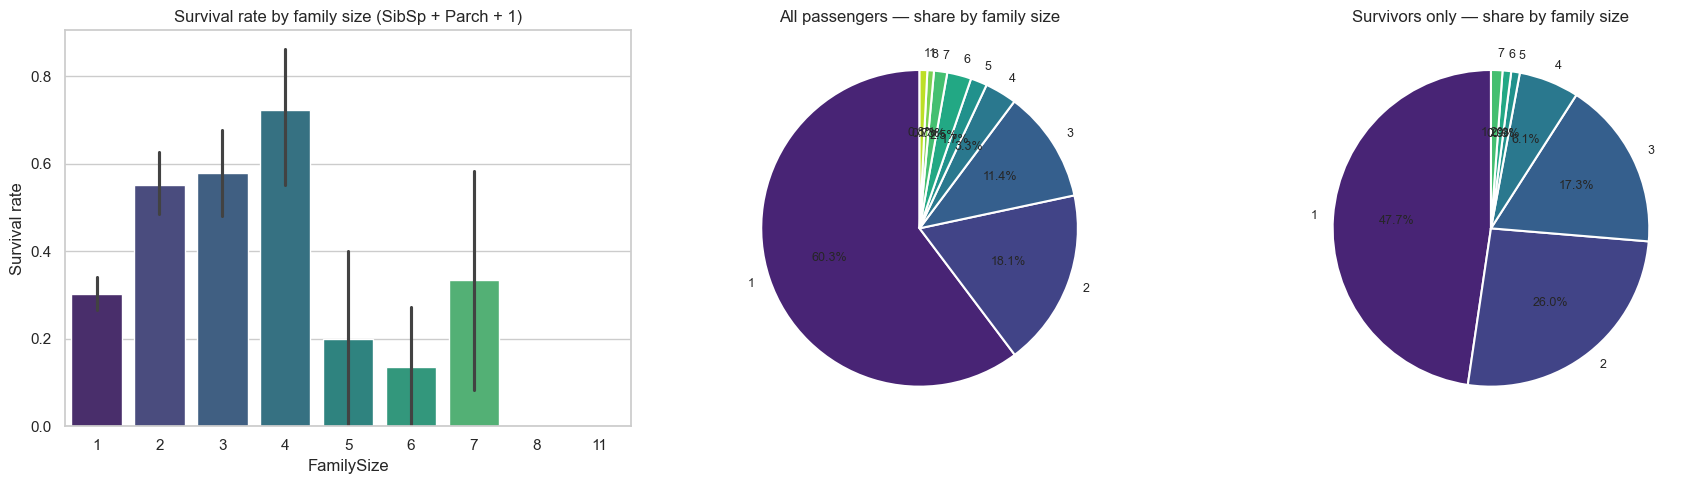

                mean  count
FamilySize                 
1           0.303538    537
2           0.552795    161
3           0.578431    102
4           0.724138     29
5           0.200000     15
6           0.136364     22
7           0.333333     12
8           0.000000      6
11          0.000000      7


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\682107021.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="FamilyBucket", y="Survived",


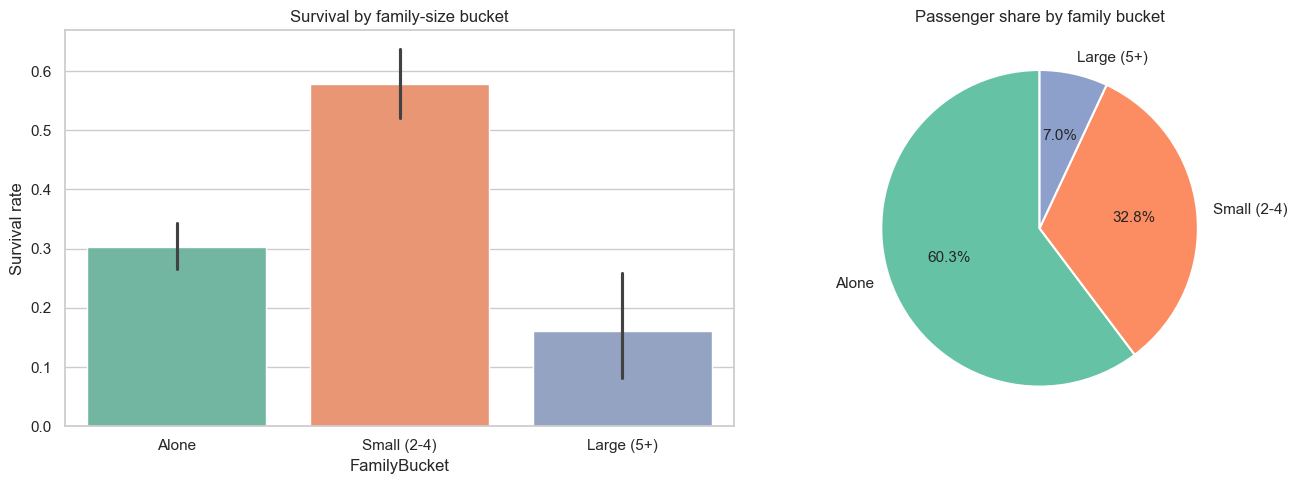

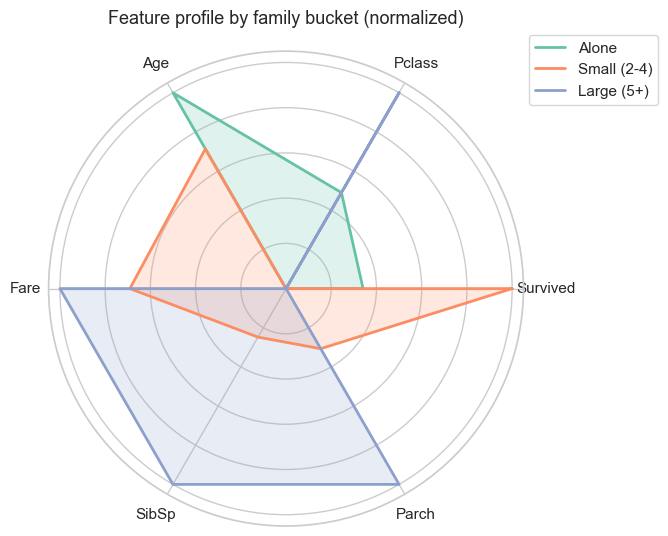

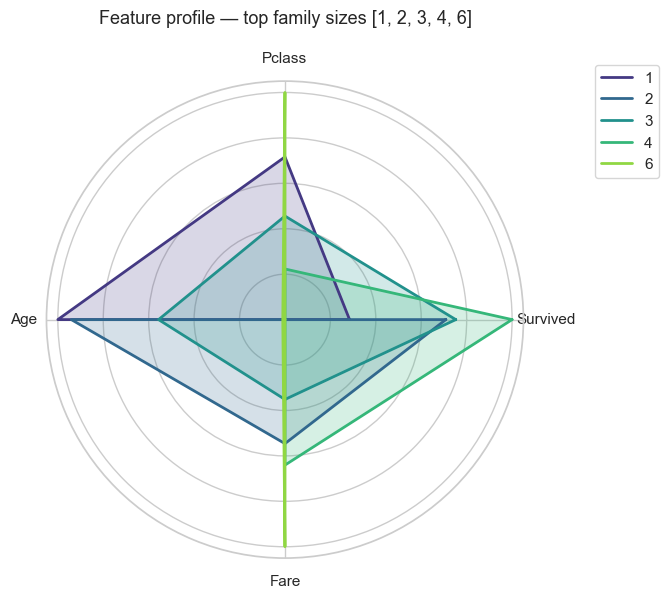

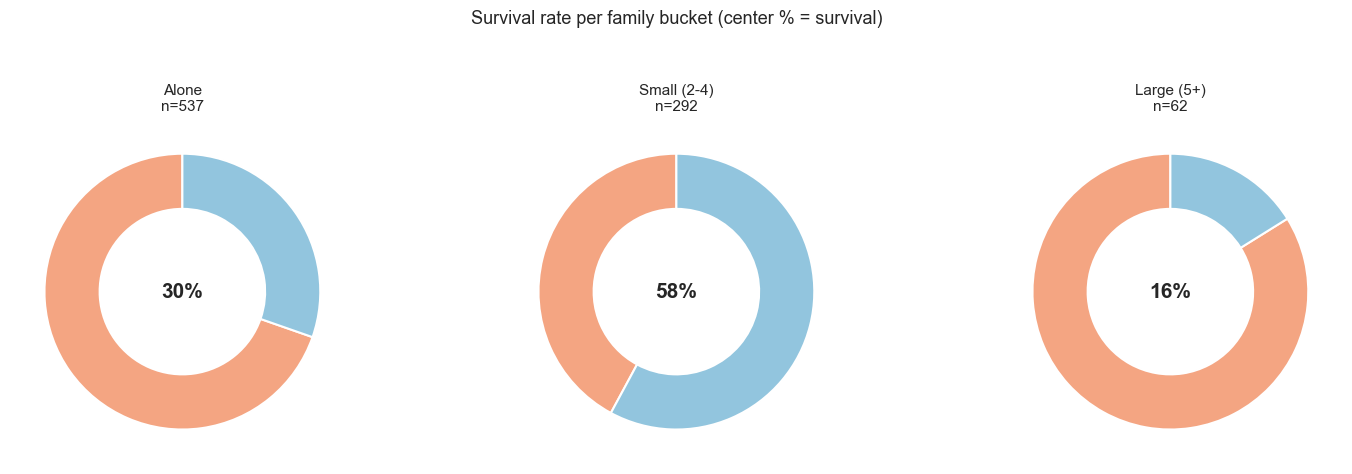

In [51]:
# Family size feature
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=train, x="FamilySize", y="Survived",
            palette="viridis", ax=axes[0])
axes[0].set_title("Survival rate by family size (SibSp + Parch + 1)")
axes[0].set_ylabel("Survival rate")

pop = train["FamilySize"].value_counts().sort_index()
colors = sns.color_palette("viridis", len(pop))
axes[1].pie(
    pop.values, labels=pop.index, autopct="%1.1f%%",
    startangle=90, colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
axes[1].set_title("All passengers — share by family size")

surv = train.loc[train["Survived"] == 1, "FamilySize"].value_counts().sort_index()
axes[2].pie(
    surv.values, labels=surv.index, autopct="%1.1f%%",
    startangle=90, colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
axes[2].set_title("Survivors only — share by family size")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_familysize.png", bbox_inches="tight")
plt.show()
plt.close()

print(train.groupby("FamilySize")["Survived"].agg(["mean", "count"]))

train["FamilyBucket"] = pd.cut(train["FamilySize"], bins=[0, 1, 4, 20],
                               labels=["Alone", "Small (2-4)", "Large (5+)"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Alone", "Small (2-4)", "Large (5+)"]

sns.barplot(data=train, x="FamilyBucket", y="Survived",
            order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Survival by family-size bucket")
axes[0].set_ylabel("Survival rate")

bucket_pop = train["FamilyBucket"].value_counts().reindex(order)
bucket_colors = sns.color_palette("Set2", len(bucket_pop))
axes[1].pie(
    bucket_pop.values, labels=bucket_pop.index, autopct="%1.1f%%",
    startangle=90, colors=bucket_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)
axes[1].set_title("Passenger share by family bucket")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_familybucket.png", bbox_inches="tight")
plt.show()
plt.close()

def radar_chart(df, group_col, feature_cols, normalize=True,
                title="Radar chart", fname="radar.png", order=None,
                palette="Set2"):
    agg = df.groupby(group_col, observed=True)[feature_cols].mean()
    if order is not None:
        agg = agg.reindex(order)
    norm = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9) if normalize else agg

    N = len(feature_cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = sns.color_palette(palette, len(norm))

    for (label, row), color in zip(norm.iterrows(), colors):
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, linewidth=2, label=str(label), color=color)
        ax.fill(angles, vals, alpha=0.20, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_cols, fontsize=11)
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.05))
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/{fname}", bbox_inches="tight")
    plt.show()
    plt.close()


# FamilyBucket radar — how do the 3 groups differ across features?
radar_chart(
    train, "FamilyBucket",
    feature_cols=["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"],
    order=order,
    title="Feature profile by family bucket (normalized)",
    fname="radar_by_familybucket.png",
    palette="Set2",
)

top_sizes = train["FamilySize"].value_counts().head(5).index.tolist()
radar_chart(
    train[train["FamilySize"].isin(top_sizes)], "FamilySize",
    feature_cols=["Survived", "Pclass", "Age", "Fare"],
    order=top_sizes,
    title=f"Feature profile — top family sizes {top_sizes}",
    fname="radar_by_familysize.png",
    palette="viridis",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, bucket in zip(axes, order):
    sub = train.loc[train["FamilyBucket"] == bucket, "Survived"] \
               .value_counts().reindex([0, 1], fill_value=0)
    ax.pie(
        sub.values,
        colors=["#f4a582", "#92c5de"],
        startangle=90,
        wedgeprops={"width": 0.40, "edgecolor": "white", "linewidth": 1.5},
    )
    rate = train.loc[train["FamilyBucket"] == bucket, "Survived"].mean()
    ax.text(0, 0, f"{rate*100:.0f}%",
            ha="center", va="center", fontsize=15, fontweight="bold")
    ax.set_title(f"{bucket}\nn={sub.sum()}", fontsize=11)

fig.suptitle("Survival rate per family bucket (center % = survival)",
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_familybucket_donuts.png", bbox_inches="tight")
plt.show()
plt.close()

# Title extracted from Name

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\838888501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="Title", y="Survived",


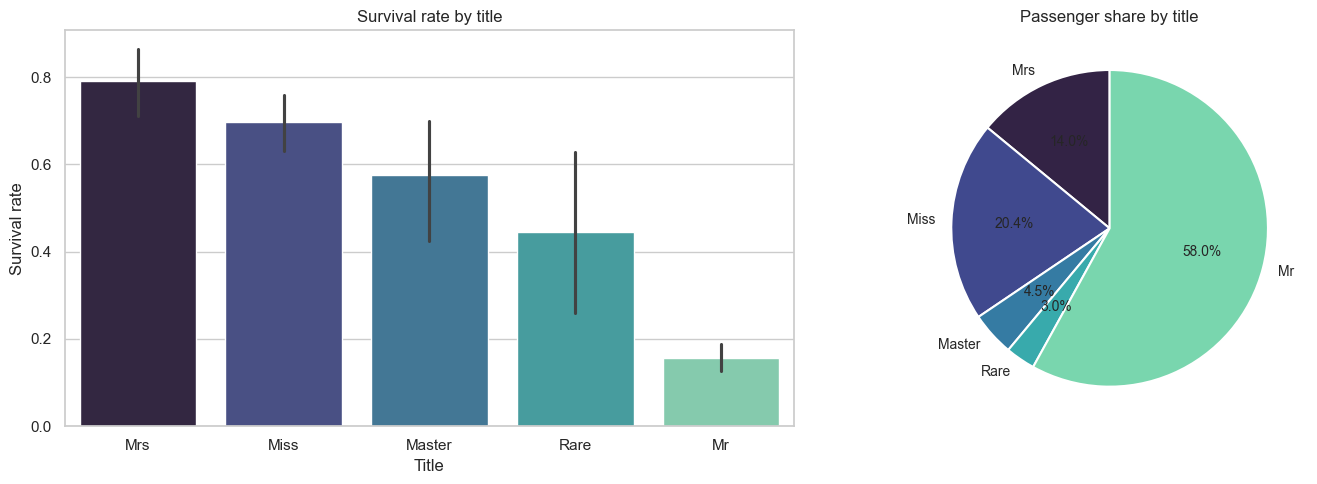

In [50]:
train["Title"] = train["Name"].str.extract(r",\s*([^\.]+)\.")
print(train["Title"].value_counts())

# Rare titles
rare = train["Title"].value_counts()[train["Title"].value_counts() < 10].index
train["Title"] = train["Title"].replace(rare, "Rare")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = train.groupby("Title")["Survived"].mean().sort_values(ascending=False).index
sns.barplot(data=train, x="Title", y="Survived",
            order=order, palette="mako", ax=axes[0])
axes[0].set_title("Survival rate by title")
axes[0].set_ylabel("Survival rate")

counts = train["Title"].value_counts().reindex(order)
colors = sns.color_palette("mako", len(counts))
axes[1].pie(
    counts.values, labels=counts.index, autopct="%1.1f%%",
    startangle=90, colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 10},
)
axes[1].set_title("Passenger share by title")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_title.png", bbox_inches="tight")
plt.show()
plt.close()

# Ticket prefix & Cabin deck

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\183691357.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="TicketPrefix", y="Survived",


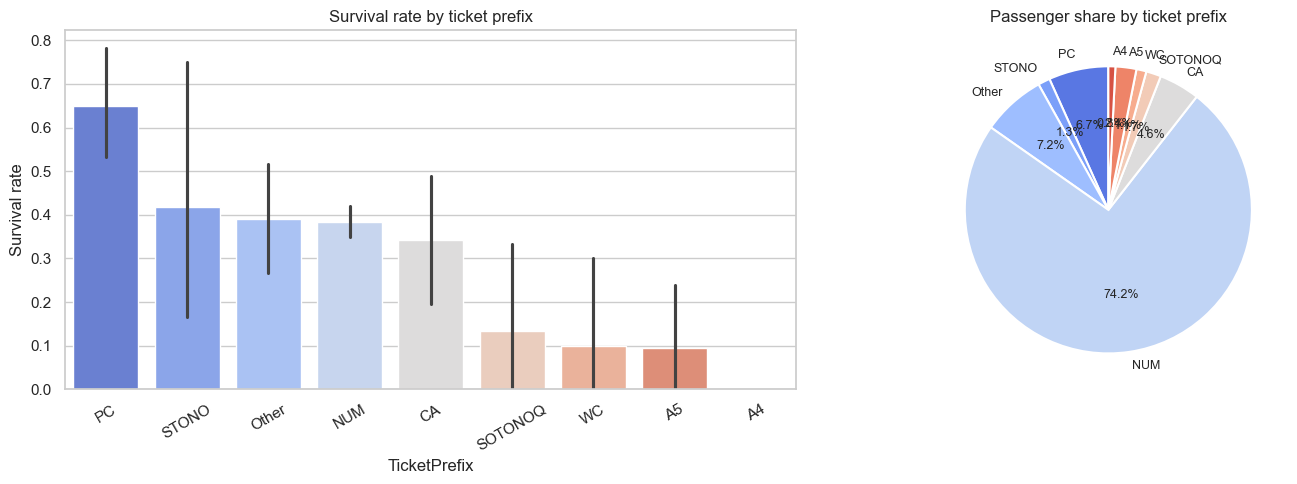

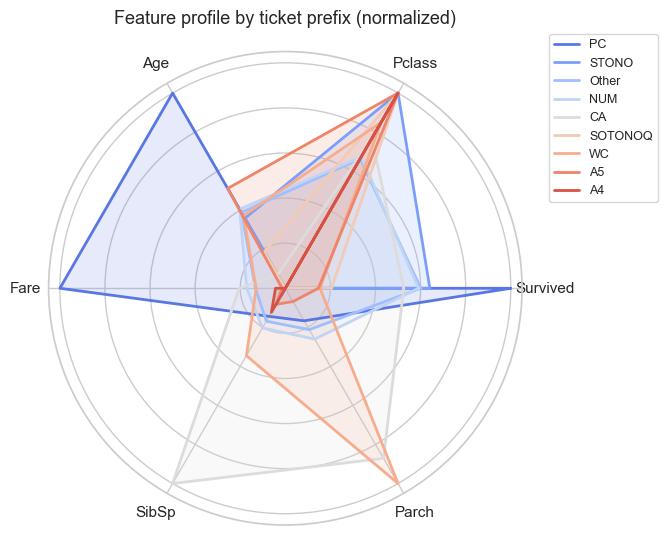

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\183691357.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="Deck", y="Survived",


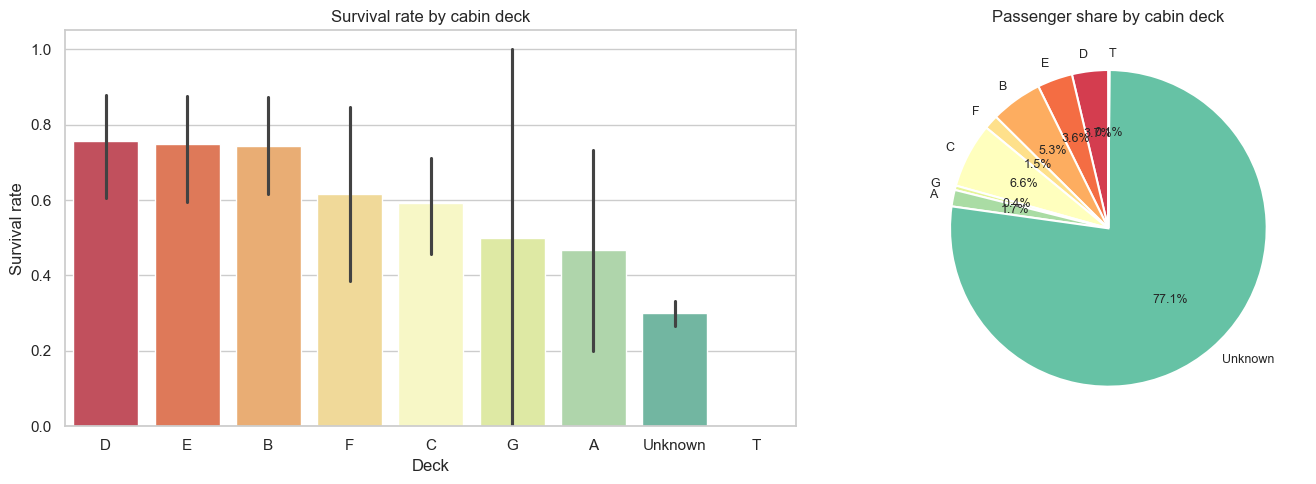

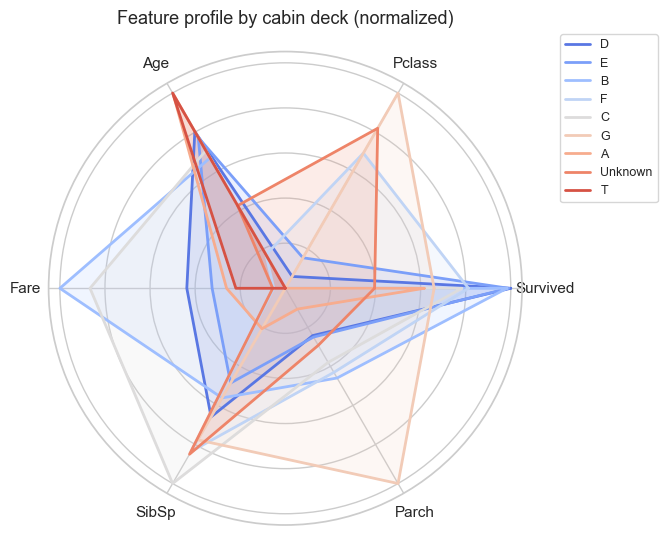

In [49]:
import numpy as np

# Ticket prefix
train["TicketPrefix"] = train["Ticket"].apply(
    lambda t: t.split()[0].replace(".", "").replace("/", "") if not t.isdigit() else "NUM"
)
train["TicketPrefix"] = train["TicketPrefix"].where(
    train["TicketPrefix"].isin(train["TicketPrefix"].value_counts().head(8).index),
    "Other"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar: survival rate
order = train.groupby("TicketPrefix")["Survived"].mean().sort_values(ascending=False).index
sns.barplot(data=train, x="TicketPrefix", y="Survived",
            order=order, palette="coolwarm", ax=axes[0])
axes[0].set_title("Survival rate by ticket prefix")
axes[0].set_ylabel("Survival rate")
axes[0].tick_params(axis="x", rotation=30)

# Pie: population share
counts = train["TicketPrefix"].value_counts().reindex(order)
colors = sns.color_palette("coolwarm", len(counts))
axes[1].pie(
    counts.values, labels=counts.index, autopct="%1.1f%%",
    startangle=90, colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
axes[1].set_title("Passenger share by ticket prefix")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_ticketprefix.png", bbox_inches="tight")
plt.show()
plt.close()

def radar_chart(df, group_col, feature_cols, normalize=True,
                title="Radar chart", fname="radar.png", order=None):
    agg = df.groupby(group_col)[feature_cols].mean()
    if order is not None:
        agg = agg.reindex(order)
    norm = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9) if normalize else agg

    N = len(feature_cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = sns.color_palette("coolwarm", len(norm))

    for (label, row), color in zip(norm.iterrows(), colors):
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, linewidth=2, label=str(label), color=color)
        ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_cols, fontsize=11)
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.05), fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/{fname}", bbox_inches="tight")
    plt.show()
    plt.close()


radar_chart(
    train, "TicketPrefix",
    feature_cols=["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"],
    order=order,
    title="Feature profile by ticket prefix (normalized)",
    fname="radar_by_ticketprefix.png",
)


# Cabin deck
train["Deck"] = train["Cabin"].str[0].fillna("Unknown")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

deck_order = train.groupby("Deck")["Survived"].mean().sort_values(ascending=False).index
sns.barplot(data=train, x="Deck", y="Survived",
            order=deck_order, palette="Spectral", ax=axes[0])
axes[0].set_title("Survival rate by cabin deck")
axes[0].set_ylabel("Survival rate")

deck_counts = train["Deck"].value_counts().reindex(deck_order)
deck_colors = sns.color_palette("Spectral", len(deck_counts))
axes[1].pie(
    deck_counts.values, labels=deck_counts.index, autopct="%1.1f%%",
    startangle=90, colors=deck_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
axes[1].set_title("Passenger share by cabin deck")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_deck.png", bbox_inches="tight")
plt.show()
plt.close()

radar_chart(
    train, "Deck",
    feature_cols=["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"],
    order=deck_order,
    title="Feature profile by cabin deck (normalized)",
    fname="radar_by_deck.png",
)

# Age distribution with KDE and bands (bin Age)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29904\3749632709.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="AgeBand", y="Survived",


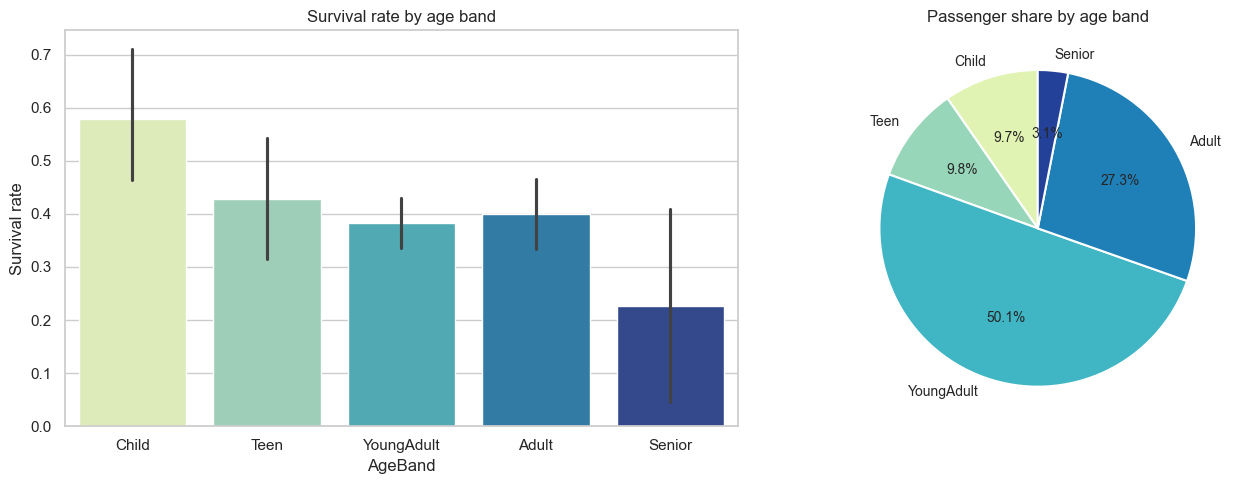

                mean  count
AgeBand                    
Child       0.579710     69
Teen        0.428571     70
YoungAdult  0.382682    358
Adult       0.400000    195
Senior      0.227273     22


In [48]:
train["AgeBand"] = pd.cut(train["Age"],
                          bins=[0, 12, 18, 35, 60, 100],
                          labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=train, x="AgeBand", y="Survived",
            palette="YlGnBu", ax=axes[0])
axes[0].set_title("Survival rate by age band")
axes[0].set_ylabel("Survival rate")

counts = train["AgeBand"].value_counts().reindex(
    ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)
colors = sns.color_palette("YlGnBu", len(counts))
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 10},
)
axes[1].set_title("Passenger share by age band")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/survival_by_ageband.png", bbox_inches="tight")
plt.show()
plt.close()

print(train.groupby("AgeBand", observed=True)["Survived"].agg(["mean", "count"]))

# key numeric features colored by target

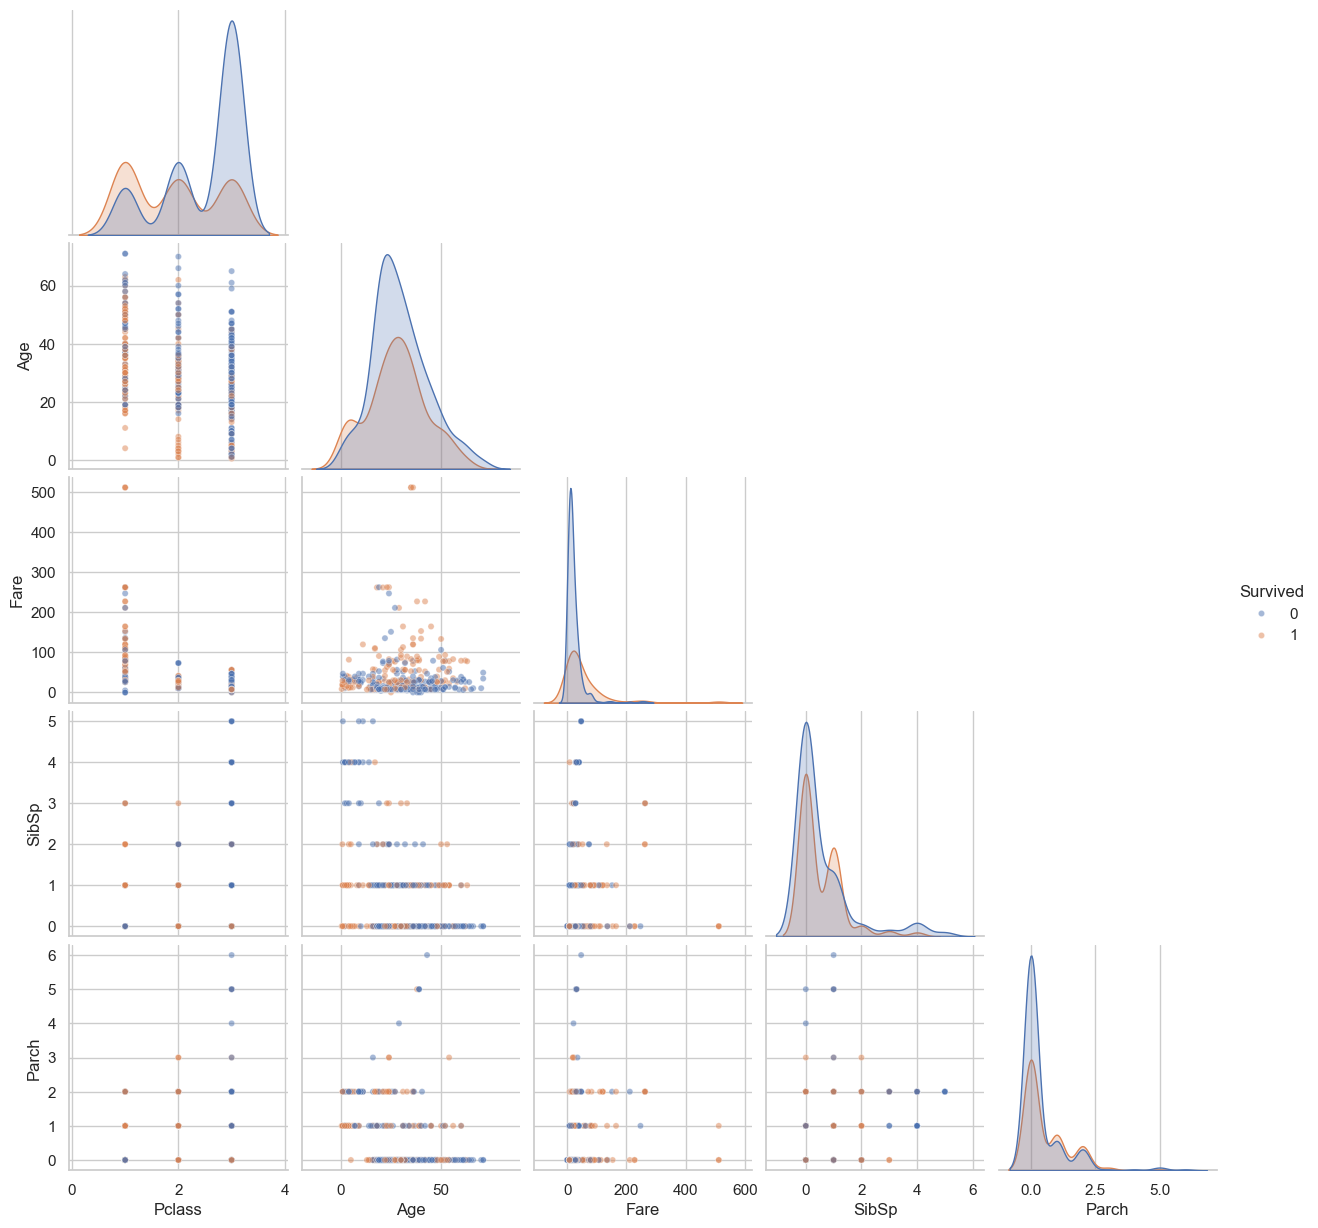

In [43]:
cols = ["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"]
sample = train[cols].dropna().sample(500, random_state=42)

sns.pairplot(sample, hue="Survived", corner=True, diag_kind="kde",
             plot_kws={"alpha": 0.5, "s": 20})
plt.savefig(f"{OUTPUT_PATH}/pairplot.png", bbox_inches="tight")
plt.show()
plt.close()

# Fare analysis (skew + log transform preview)

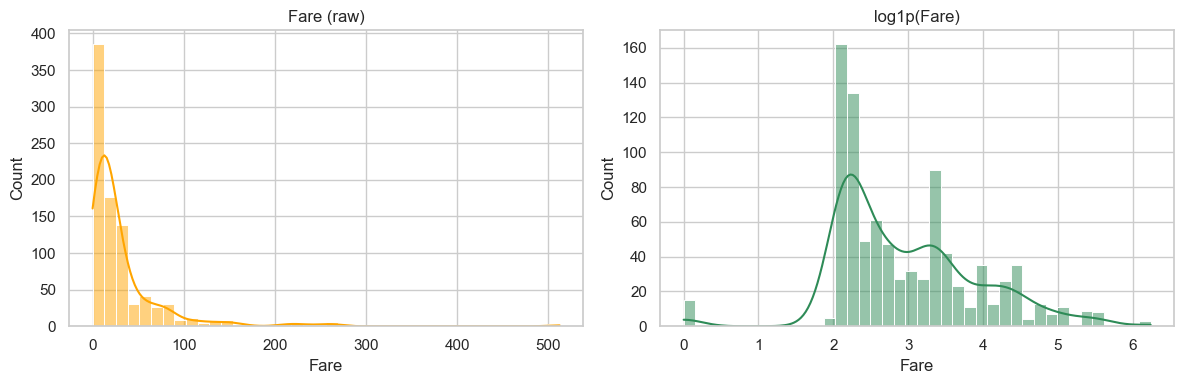

Skewness raw : 4.787
Skewness log : 0.395


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["Fare"], kde=True, bins=40, ax=axes[0], color="orange")
axes[0].set_title("Fare (raw)")

sns.histplot(np.log1p(train["Fare"]), kde=True, bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(Fare)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/fare_log.png", bbox_inches="tight")
plt.show()
plt.close()

print("Skewness raw :", train["Fare"].skew().round(3))
print("Skewness log :", np.log1p(train["Fare"]).skew().round(3))

# Grouped summary table (quick textual EDA)

In [47]:
def summary(df, col, target="Survived"):
    g = df.groupby(col)[target].agg(["mean", "count"])
    g["mean"] = g["mean"].round(4)
    return g.sort_values("mean", ascending=False)

for c in ["Sex", "Pclass", "Embarked", "Title", "FamilyBucket", "AgeBand", "Deck"]:
    if c in train.columns:
        print(f"\n=== {c} ===")
        print(summary(train, c))


=== Sex ===
          mean  count
Sex                  
female  0.7420    314
male    0.1889    577

=== Pclass ===
          mean  count
Pclass               
1       0.6296    216
2       0.4728    184
3       0.2424    491

=== Embarked ===
            mean  count
Embarked               
C         0.5536    168
Q         0.3896     77
S         0.3370    644

=== Title ===
          mean  count
Title                
Mrs     0.7920    125
Miss    0.6978    182
Master  0.5750     40
Rare    0.4444     27
Mr      0.1567    517

=== FamilyBucket ===
                mean  count
FamilyBucket               
Small (2-4)   0.5788    292
Alone         0.3035    537
Large (5+)    0.1613     62

=== AgeBand ===
              mean  count
AgeBand                  
Child       0.5797     69
Teen        0.4286     70
Adult       0.4000    195
YoungAdult  0.3827    358
Senior      0.2273     22

=== Deck ===
           mean  count
Deck                  
D        0.7576     33
E        0.7500     32